# Домашнее задание

**Студент:** Тавуз Мохамад  
**Группа:** ИУ5И-22М  

**Тема:** Сравнительный анализ методов обучения с подкреплением для задач управления агентом в средах Taxi-v4 и CartPole-v1.

# Подготовка среды выполнения

В данном разделе выполняется установка и импорт библиотек, необходимых для проведения экспериментов по обучению с подкреплением. Также проверяется доступность GPU и создаются папки для сохранения результатов экспериментов.

In [1]:
# Подготовка библиотек, проверка устройства и создание папок для результатов

!pip -q install gymnasium[toy-text] numpy pandas matplotlib tqdm torch torchvision

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import gymnasium as gym

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Фиксация random seed для воспроизводимости экспериментов
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Выбор устройства для обучения нейронных сетей
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Создание папок для сохранения результатов
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Библиотеки успешно импортированы")
print("Версия Gymnasium:", gym.__version__)
print("Версия NumPy:", np.__version__)
print("Версия Pandas:", pd.__version__)
print("Версия PyTorch:", torch.__version__)
print("Используемое устройство:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 56.0 MB/s eta 0:00:00
Библиотеки успешно импортированы
Версия Gymnasium: 1.3.0
Версия NumPy: 2.0.2
Версия Pandas: 2.2.2
Версия PyTorch: 2.11.0+cu128
Используемое устройство: cuda


# Исследование среды Taxi-v4

В данном разделе создается среда Taxi-v4 из библиотеки Gymnasium. Выполняется анализ пространства состояний, пространства действий, диапазона наград и структуры переходов среды. Эта среда будет использоваться далее для реализации табличных методов обучения с подкреплением.

In [6]:
# Создание среды Taxi-v4 и вывод ее основных характеристик

env = gym.make("Taxi-v4")
state, info = env.reset(seed=SEED)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Среда:", "Taxi-v4")
print("Пространство состояний:", env.observation_space)
print("Количество состояний:", n_states)
print("Пространство действий:", env.action_space)
print("Количество действий:", n_actions)
print("Начальное состояние:", state)

sample_state = 54
sample_action = 0

print("\nПример структуры переходов")
print("Состояние:", sample_state)
print("Действие:", sample_action)
print("Переходы:")

for transition in env.unwrapped.P[sample_state][sample_action]:
    probability, next_state, reward, terminated = transition
    print(
        "probability =", probability,
        "| next_state =", next_state,
        "| reward =", reward,
        "| terminated =", terminated
    )

Среда: Taxi-v4
Пространство состояний: Discrete(500)
Количество состояний: 500
Пространство действий: Discrete(6)
Количество действий: 6
Начальное состояние: 386

Пример структуры переходов
Состояние: 54
Действие: 0
Переходы:
probability = 1.0 | next_state = 154 | reward = -1 | terminated = False


# Функции оценки качества обученного агента

В данном разделе реализуются вспомогательные функции для оценки качества стратегии агента. Оценка выполняется на нескольких тестовых эпизодах по средней суммарной награде, среднему количеству шагов и доле успешных эпизодов.

In [7]:
# Реализация функций для тестирования стратегии агента

def reset_env(environment, seed=None):
    result = environment.reset(seed=seed)
    if isinstance(result, tuple):
        return result[0]
    return result


def step_env(environment, action):
    result = environment.step(action)
    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
        done = terminated or truncated
        return next_state, reward, done, info
    else:
        next_state, reward, done, info = result
        return next_state, reward, done, info


def evaluate_policy(environment, policy, episodes=100, max_steps=200, seed=42):
    total_rewards = []
    total_steps = []
    successful_episodes = 0

    for episode in range(episodes):
        state = reset_env(environment, seed=seed + episode)
        episode_reward = 0
        steps = 0
        done = False

        while not done and steps < max_steps:
            action = int(policy[state])
            next_state, reward, done, info = step_env(environment, action)

            episode_reward += reward
            steps += 1
            state = next_state

        total_rewards.append(episode_reward)
        total_steps.append(steps)

        if episode_reward > 0:
            successful_episodes += 1

    results = {
        "Средняя награда": np.mean(total_rewards),
        "Среднее количество шагов": np.mean(total_steps),
        "Доля успешных эпизодов": successful_episodes / episodes
    }

    return results

# Реализация алгоритма Policy Iteration

В данном разделе реализуется алгоритм Policy Iteration для среды Taxi-v4. Алгоритм состоит из двух основных этапов: оценивания текущей стратегии и улучшения стратегии. Процесс повторяется до стабилизации стратегии.

In [8]:
# Реализация алгоритма Policy Iteration для среды Taxi-v4

class PolicyIterationAgent:
    def __init__(self, environment, gamma=0.99, theta=1e-8, max_iterations=1000):
        self.env = environment
        self.n_states = environment.observation_space.n
        self.n_actions = environment.action_space.n
        self.gamma = gamma
        self.theta = theta
        self.max_iterations = max_iterations

        self.policy = np.zeros(self.n_states, dtype=int)
        self.value_function = np.zeros(self.n_states)

    def policy_evaluation(self):
        for _ in range(self.max_iterations):
            delta = 0

            for state in range(self.n_states):
                old_value = self.value_function[state]
                action = self.policy[state]

                new_value = 0
                for probability, next_state, reward, terminated in self.env.unwrapped.P[state][action]:
                    new_value += probability * (
                        reward + self.gamma * self.value_function[next_state] * (not terminated)
                    )

                self.value_function[state] = new_value
                delta = max(delta, abs(old_value - new_value))

            if delta < self.theta:
                break

    def policy_improvement(self):
        policy_stable = True

        for state in range(self.n_states):
            old_action = self.policy[state]
            q_values = np.zeros(self.n_actions)

            for action in range(self.n_actions):
                for probability, next_state, reward, terminated in self.env.unwrapped.P[state][action]:
                    q_values[action] += probability * (
                        reward + self.gamma * self.value_function[next_state] * (not terminated)
                    )

            best_action = np.argmax(q_values)
            self.policy[state] = best_action

            if old_action != best_action:
                policy_stable = False

        return policy_stable

    def train(self):
        start_time = time.time()

        for iteration in range(1, self.max_iterations + 1):
            self.policy_evaluation()
            policy_stable = self.policy_improvement()

            if policy_stable:
                break

        training_time = time.time() - start_time

        return {
            "Алгоритм": "Policy Iteration",
            "Количество итераций": iteration,
            "Время обучения, сек": training_time
        }


policy_iteration_agent = PolicyIterationAgent(env)
policy_iteration_training_results = policy_iteration_agent.train()

print("Результаты обучения Policy Iteration")
for key, value in policy_iteration_training_results.items():
    print(key, ":", value)

Результаты обучения Policy Iteration
Алгоритм : Policy Iteration
Количество итераций : 17
Время обучения, сек : 1.6183295249938965


In [9]:
# Оценка качества стратегии, полученной алгоритмом Policy Iteration

policy_iteration_eval_results = evaluate_policy(
    environment=env,
    policy=policy_iteration_agent.policy,
    episodes=100,
    max_steps=200,
    seed=SEED
)

print("Оценка качества Policy Iteration")
for key, value in policy_iteration_eval_results.items():
    print(key, ":", value)

Оценка качества Policy Iteration
Средняя награда : 7.34
Среднее количество шагов : 13.66
Доля успешных эпизодов : 1.0


# Реализация алгоритмов SARSA, Q-Learning и Double Q-Learning

В данном разделе реализуются табличные методы обучения с подкреплением на основе временных различий: SARSA, Q-Learning и Double Q-Learning. Для выбора действий используется epsilon-greedy стратегия, а обучение выполняется на среде Taxi-v4.

In [10]:
# Реализация базового класса агента и алгоритмов SARSA, Q-Learning, Double Q-Learning

class BaseTDAgent:
    def __init__(
        self,
        environment,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.9995,
        episodes=8000,
        max_steps=200
    ):
        self.env = environment
        self.n_states = environment.observation_space.n
        self.n_actions = environment.action_space.n

        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.episodes = episodes
        self.max_steps = max_steps

        self.Q = np.zeros((self.n_states, self.n_actions))
        self.episode_rewards = []
        self.episode_steps = []

    def choose_action(self, state):
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        return int(np.argmax(self.Q[state]))

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def get_policy(self):
        return np.argmax(self.Q, axis=1)


class SARSAAgent(BaseTDAgent):
    def train(self):
        start_time = time.time()

        for episode in tqdm(range(self.episodes), desc="SARSA"):
            state = reset_env(self.env, seed=SEED + episode)
            action = self.choose_action(state)

            total_reward = 0
            steps = 0
            done = False

            while not done and steps < self.max_steps:
                next_state, reward, done, info = step_env(self.env, action)
                next_action = self.choose_action(next_state)

                target = reward + self.gamma * self.Q[next_state, next_action] * (not done)
                self.Q[state, action] += self.alpha * (target - self.Q[state, action])

                state = next_state
                action = next_action
                total_reward += reward
                steps += 1

            self.episode_rewards.append(total_reward)
            self.episode_steps.append(steps)
            self.decay_epsilon()

        training_time = time.time() - start_time

        return {
            "Алгоритм": "SARSA",
            "Количество эпизодов": self.episodes,
            "Время обучения, сек": training_time,
            "Финальное epsilon": self.epsilon
        }


class QLearningAgent(BaseTDAgent):
    def train(self):
        start_time = time.time()

        for episode in tqdm(range(self.episodes), desc="Q-Learning"):
            state = reset_env(self.env, seed=SEED + episode)

            total_reward = 0
            steps = 0
            done = False

            while not done and steps < self.max_steps:
                action = self.choose_action(state)
                next_state, reward, done, info = step_env(self.env, action)

                target = reward + self.gamma * np.max(self.Q[next_state]) * (not done)
                self.Q[state, action] += self.alpha * (target - self.Q[state, action])

                state = next_state
                total_reward += reward
                steps += 1

            self.episode_rewards.append(total_reward)
            self.episode_steps.append(steps)
            self.decay_epsilon()

        training_time = time.time() - start_time

        return {
            "Алгоритм": "Q-Learning",
            "Количество эпизодов": self.episodes,
            "Время обучения, сек": training_time,
            "Финальное epsilon": self.epsilon
        }


class DoubleQLearningAgent(BaseTDAgent):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.Q1 = np.zeros((self.n_states, self.n_actions))
        self.Q2 = np.zeros((self.n_states, self.n_actions))

    def choose_action(self, state):
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        return int(np.argmax(self.Q1[state] + self.Q2[state]))

    def get_policy(self):
        return np.argmax(self.Q1 + self.Q2, axis=1)

    def train(self):
        start_time = time.time()

        for episode in tqdm(range(self.episodes), desc="Double Q-Learning"):
            state = reset_env(self.env, seed=SEED + episode)

            total_reward = 0
            steps = 0
            done = False

            while not done and steps < self.max_steps:
                action = self.choose_action(state)
                next_state, reward, done, info = step_env(self.env, action)

                if np.random.random() < 0.5:
                    best_next_action = np.argmax(self.Q1[next_state])
                    target = reward + self.gamma * self.Q2[next_state, best_next_action] * (not done)
                    self.Q1[state, action] += self.alpha * (target - self.Q1[state, action])
                else:
                    best_next_action = np.argmax(self.Q2[next_state])
                    target = reward + self.gamma * self.Q1[next_state, best_next_action] * (not done)
                    self.Q2[state, action] += self.alpha * (target - self.Q2[state, action])

                state = next_state
                total_reward += reward
                steps += 1

            self.episode_rewards.append(total_reward)
            self.episode_steps.append(steps)
            self.decay_epsilon()

        self.Q = self.Q1 + self.Q2
        training_time = time.time() - start_time

        return {
            "Алгоритм": "Double Q-Learning",
            "Количество эпизодов": self.episodes,
            "Время обучения, сек": training_time,
            "Финальное epsilon": self.epsilon
        }

In [11]:
# Обучение агентов SARSA, Q-Learning и Double Q-Learning на среде Taxi-v4

sarsa_agent = SARSAAgent(env)
q_learning_agent = QLearningAgent(env)
double_q_learning_agent = DoubleQLearningAgent(env)

sarsa_training_results = sarsa_agent.train()
q_learning_training_results = q_learning_agent.train()
double_q_learning_training_results = double_q_learning_agent.train()

training_results_df = pd.DataFrame([
    sarsa_training_results,
    q_learning_training_results,
    double_q_learning_training_results
])

display(training_results_df)

Double Q-Learning: 100%|██████████| 8000/8000 [00:12<00:00, 635.61it/s] 


,Алгоритм,Количество эпизодов,"Время обучения, сек",Финальное epsilon
0,SARSA,8000,10.419275,0.05
1,Q-Learning,8000,10.804644,0.05
2,Double Q-Learning,8000,12.591701,0.05


In [12]:
# Оценка качества стратегий SARSA, Q-Learning и Double Q-Learning

sarsa_eval_results = evaluate_policy(
    environment=env,
    policy=sarsa_agent.get_policy(),
    episodes=100,
    max_steps=200,
    seed=SEED
)

q_learning_eval_results = evaluate_policy(
    environment=env,
    policy=q_learning_agent.get_policy(),
    episodes=100,
    max_steps=200,
    seed=SEED
)

double_q_learning_eval_results = evaluate_policy(
    environment=env,
    policy=double_q_learning_agent.get_policy(),
    episodes=100,
    max_steps=200,
    seed=SEED
)

td_eval_results_df = pd.DataFrame([
    {"Алгоритм": "SARSA", **sarsa_eval_results},
    {"Алгоритм": "Q-Learning", **q_learning_eval_results},
    {"Алгоритм": "Double Q-Learning", **double_q_learning_eval_results}
])

display(td_eval_results_df)

,Алгоритм,Средняя награда,Среднее количество шагов,Доля успешных эпизодов
0,SARSA,7.30,13.70,1.0
1,Q-Learning,7.34,13.66,1.0
2,Double Q-Learning,7.34,13.66,1.0


# Визуализация процесса обучения табличных алгоритмов

В данном разделе строятся графики изменения суммарной награды и количества шагов по эпизодам для алгоритмов SARSA, Q-Learning и Double Q-Learning. Для сглаживания кривых используется скользящее среднее.

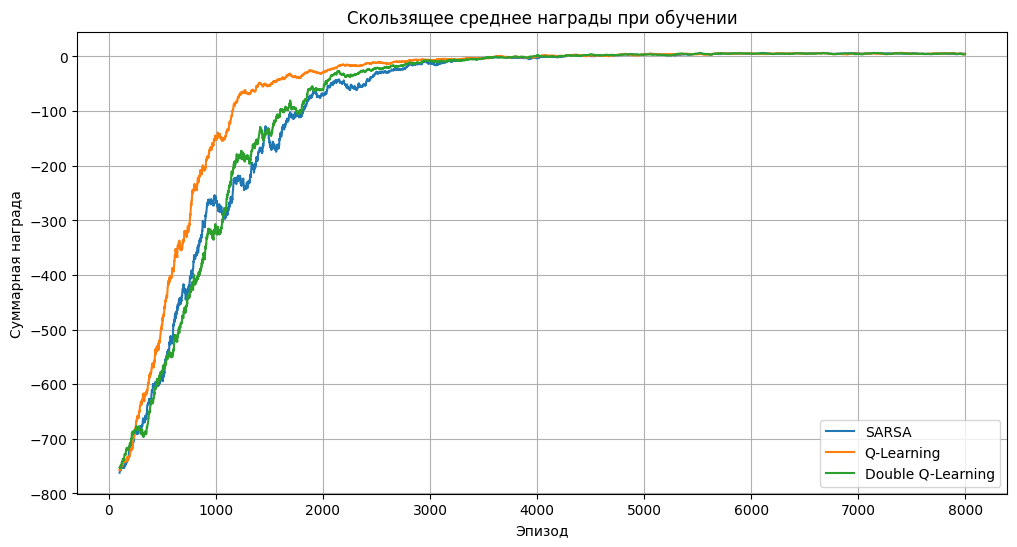

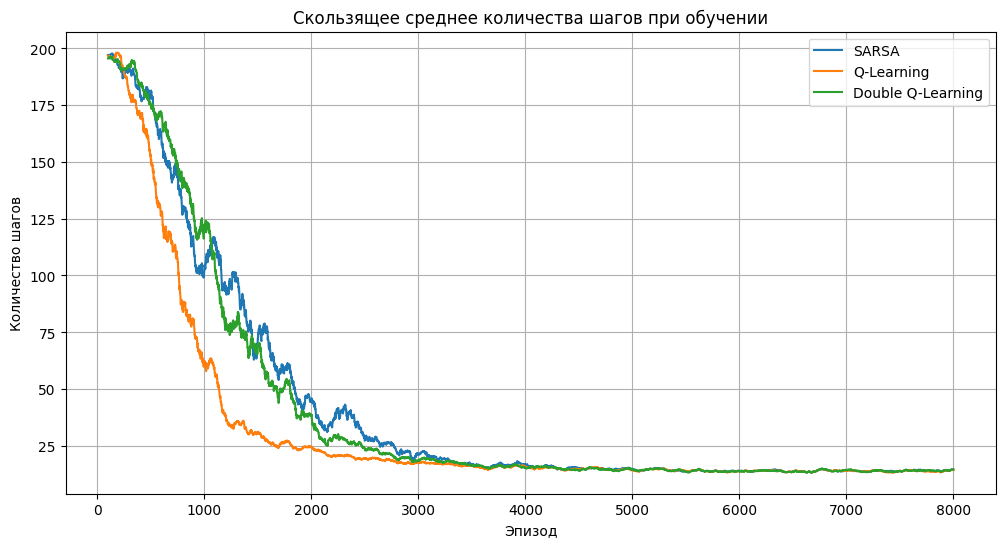

In [13]:
# Построение графиков наград и количества шагов при обучении табличных алгоритмов

def moving_average(values, window=100):
    return pd.Series(values).rolling(window=window).mean()


window = 100

plt.figure(figsize=(12, 6))
plt.plot(moving_average(sarsa_agent.episode_rewards, window), label="SARSA")
plt.plot(moving_average(q_learning_agent.episode_rewards, window), label="Q-Learning")
plt.plot(moving_average(double_q_learning_agent.episode_rewards, window), label="Double Q-Learning")
plt.title("Скользящее среднее награды при обучении")
plt.xlabel("Эпизод")
plt.ylabel("Суммарная награда")
plt.legend()
plt.grid(True)
plt.savefig("figures/td_rewards_moving_average.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(moving_average(sarsa_agent.episode_steps, window), label="SARSA")
plt.plot(moving_average(q_learning_agent.episode_steps, window), label="Q-Learning")
plt.plot(moving_average(double_q_learning_agent.episode_steps, window), label="Double Q-Learning")
plt.title("Скользящее среднее количества шагов при обучении")
plt.xlabel("Эпизод")
plt.ylabel("Количество шагов")
plt.legend()
plt.grid(True)
plt.savefig("figures/td_steps_moving_average.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Формирование итоговой таблицы сравнения табличных алгоритмов

policy_iteration_summary = {
    "Алгоритм": "Policy Iteration",
    "Количество эпизодов": "-",
    "Количество итераций": policy_iteration_training_results["Количество итераций"],
    "Время обучения, сек": policy_iteration_training_results["Время обучения, сек"],
    **policy_iteration_eval_results
}

sarsa_summary = {
    "Алгоритм": "SARSA",
    "Количество эпизодов": sarsa_training_results["Количество эпизодов"],
    "Количество итераций": "-",
    "Время обучения, сек": sarsa_training_results["Время обучения, сек"],
    **sarsa_eval_results
}

q_learning_summary = {
    "Алгоритм": "Q-Learning",
    "Количество эпизодов": q_learning_training_results["Количество эпизодов"],
    "Количество итераций": "-",
    "Время обучения, сек": q_learning_training_results["Время обучения, сек"],
    **q_learning_eval_results
}

double_q_learning_summary = {
    "Алгоритм": "Double Q-Learning",
    "Количество эпизодов": double_q_learning_training_results["Количество эпизодов"],
    "Количество итераций": "-",
    "Время обучения, сек": double_q_learning_training_results["Время обучения, сек"],
    **double_q_learning_eval_results
}

tabular_comparison_df = pd.DataFrame([
    policy_iteration_summary,
    sarsa_summary,
    q_learning_summary,
    double_q_learning_summary
])

tabular_comparison_df.to_csv("results/tabular_algorithms_comparison.csv", index=False)

display(tabular_comparison_df)

,Алгоритм,Количество эпизодов,Количество итераций,"Время обучения, сек",Средняя награда,Среднее количество шагов,Доля успешных эпизодов
0,Policy Iteration,-,17,1.618330,7.34,13.66,1.0
1,SARSA,8000,-,10.419275,7.30,13.70,1.0
2,Q-Learning,8000,-,10.804644,7.34,13.66,1.0
3,Double Q-Learning,8000,-,12.591701,7.34,13.66,1.0


# Исследование среды CartPole-v1

В данном разделе создается среда CartPole-v1 из библиотеки Gymnasium. Среда используется для реализации алгоритма Deep Q-Network. В отличие от Taxi-v4, пространство наблюдений здесь является непрерывным, поэтому для аппроксимации Q-функции будет использоваться нейронная сеть.

In [15]:
# Создание среды CartPole-v1 и вывод ее основных характеристик

cartpole_env = gym.make("CartPole-v1")
state, info = cartpole_env.reset(seed=SEED)

cartpole_n_observations = cartpole_env.observation_space.shape[0]
cartpole_n_actions = cartpole_env.action_space.n

print("Среда:", "CartPole-v1")
print("Пространство наблюдений:", cartpole_env.observation_space)
print("Количество признаков состояния:", cartpole_n_observations)
print("Пространство действий:", cartpole_env.action_space)
print("Количество действий:", cartpole_n_actions)
print("Начальное состояние:")
print(state)

Среда: CartPole-v1
Пространство наблюдений: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Количество признаков состояния: 4
Пространство действий: Discrete(2)
Количество действий: 2
Начальное состояние:
[ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


# Реализация Replay Buffer и нейронной сети DQN

В данном разделе реализуются основные компоненты алгоритма Deep Q-Network: буфер воспроизведения опыта Replay Buffer и полносвязная нейронная сеть для аппроксимации Q-функции. Нейронная сеть получает состояние среды CartPole-v1 и возвращает Q-значения для двух возможных действий.

In [16]:
# Реализация Replay Buffer и нейронной сети DQN для среды CartPole-v1

from collections import deque, namedtuple

Transition = namedtuple(
    "Transition",
    ("state", "action", "reward", "next_state", "done")
)


class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append(
            Transition(state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        transitions = random.sample(self.memory, batch_size)
        return Transition(*zip(*transitions))

    def __len__(self):
        return len(self.memory)


class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(n_observations, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.network(x)


test_dqn_model = DQN(cartpole_n_observations, cartpole_n_actions).to(device)

print("Архитектура DQN:")
print(test_dqn_model)

Архитектура DQN:
DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


# Реализация агента DQN

В данном разделе реализуется агент Deep Q-Network для среды CartPole-v1. Агент использует epsilon-greedy стратегию выбора действий, Replay Buffer для хранения опыта, основную нейронную сеть и целевую нейронную сеть для стабилизации обучения.

In [17]:
# Реализация агента DQN для среды CartPole-v1

class DQNAgent:
    def __init__(
        self,
        environment,
        batch_size=128,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.995,
        learning_rate=1e-3,
        target_update_frequency=10,
        memory_capacity=10000
    ):
        self.env = environment
        self.n_observations = environment.observation_space.shape[0]
        self.n_actions = environment.action_space.n

        self.batch_size = batch_size
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.learning_rate = learning_rate
        self.target_update_frequency = target_update_frequency

        self.policy_net = DQN(self.n_observations, self.n_actions).to(device)
        self.target_net = DQN(self.n_observations, self.n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.learning_rate)
        self.memory = ReplayBuffer(capacity=memory_capacity)

        self.episode_rewards = []
        self.episode_steps = []
        self.losses = []

    def choose_action(self, state):
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()

        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            q_values = self.policy_net(state_tensor)

        return int(torch.argmax(q_values).item())

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return None

        transitions = self.memory.sample(self.batch_size)

        states = torch.tensor(np.array(transitions.state), dtype=torch.float32, device=device)
        actions = torch.tensor(transitions.action, dtype=torch.long, device=device).unsqueeze(1)
        rewards = torch.tensor(transitions.reward, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(transitions.next_state), dtype=torch.float32, device=device)
        dones = torch.tensor(transitions.done, dtype=torch.float32, device=device).unsqueeze(1)

        current_q_values = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + self.gamma * next_q_values * (1 - dones)

        loss = F.mse_loss(current_q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def train(self, episodes=500, max_steps=500):
        start_time = time.time()

        for episode in tqdm(range(episodes), desc="DQN"):
            state, info = self.env.reset(seed=SEED + episode)

            total_reward = 0
            steps = 0
            done = False

            while not done and steps < max_steps:
                action = self.choose_action(state)
                next_state, reward, terminated, truncated, info = self.env.step(action)
                done = terminated or truncated

                self.memory.push(state, action, reward, next_state, done)

                loss = self.optimize_model()
                if loss is not None:
                    self.losses.append(loss)

                state = next_state
                total_reward += reward
                steps += 1

            self.episode_rewards.append(total_reward)
            self.episode_steps.append(steps)

            self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

            if episode % self.target_update_frequency == 0:
                self.target_net.load_state_dict(self.policy_net.state_dict())

        training_time = time.time() - start_time

        return {
            "Алгоритм": "DQN",
            "Количество эпизодов": episodes,
            "Время обучения, сек": training_time,
            "Финальное epsilon": self.epsilon,
            "Средняя награда за последние 50 эпизодов": np.mean(self.episode_rewards[-50:])
        }


print("Класс DQNAgent успешно создан")

Класс DQNAgent успешно создан


In [18]:
# Обучение агента DQN на среде CartPole-v1

dqn_agent = DQNAgent(cartpole_env)

dqn_training_results = dqn_agent.train(
    episodes=500,
    max_steps=500
)

dqn_training_results_df = pd.DataFrame([dqn_training_results])

display(dqn_training_results_df)

DQN: 100%|██████████| 500/500 [02:33<00:00,  3.26it/s]


,Алгоритм,Количество эпизодов,"Время обучения, сек",Финальное epsilon,Средняя награда за последние 50 эпизодов
0,DQN,500,153.379056,0.081572,216.58


In [19]:
# Оценка качества обученного агента DQN на тестовых эпизодах

def evaluate_dqn_agent(environment, agent, episodes=100, max_steps=500, seed=42):
    total_rewards = []
    total_steps = []

    old_epsilon = agent.epsilon
    agent.epsilon = 0.0

    for episode in range(episodes):
        state, info = environment.reset(seed=seed + episode)

        episode_reward = 0
        steps = 0
        done = False

        while not done and steps < max_steps:
            action = agent.choose_action(state)
            next_state, reward, terminated, truncated, info = environment.step(action)
            done = terminated or truncated

            episode_reward += reward
            steps += 1
            state = next_state

        total_rewards.append(episode_reward)
        total_steps.append(steps)

    agent.epsilon = old_epsilon

    results = {
        "Алгоритм": "DQN",
        "Количество тестовых эпизодов": episodes,
        "Средняя награда": np.mean(total_rewards),
        "Среднее количество шагов": np.mean(total_steps),
        "Максимальная награда": np.max(total_rewards),
        "Минимальная награда": np.min(total_rewards)
    }

    return results


dqn_eval_results = evaluate_dqn_agent(
    environment=cartpole_env,
    agent=dqn_agent,
    episodes=100,
    max_steps=500,
    seed=SEED
)

dqn_eval_results_df = pd.DataFrame([dqn_eval_results])

display(dqn_eval_results_df)

,Алгоритм,Количество тестовых эпизодов,Средняя награда,Среднее количество шагов,Максимальная награда,Минимальная награда
0,DQN,100,500.0,500.0,500.0,500.0


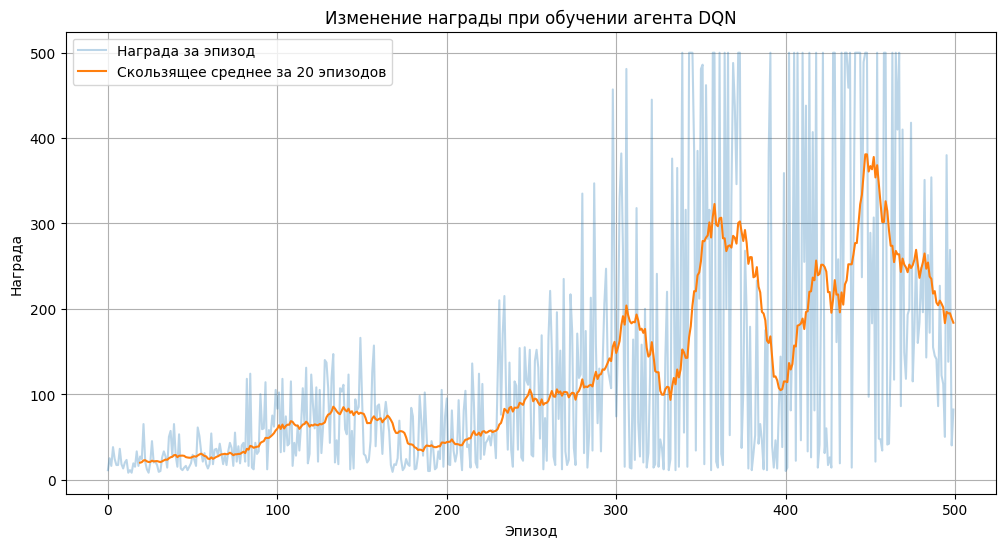

In [20]:
# Построение графика награды при обучении агента DQN

dqn_rewards_moving_average = pd.Series(dqn_agent.episode_rewards).rolling(window=20).mean()

plt.figure(figsize=(12, 6))
plt.plot(dqn_agent.episode_rewards, alpha=0.3, label="Награда за эпизод")
plt.plot(dqn_rewards_moving_average, label="Скользящее среднее за 20 эпизодов")
plt.title("Изменение награды при обучении агента DQN")
plt.xlabel("Эпизод")
plt.ylabel("Награда")
plt.legend()
plt.grid(True)
plt.savefig("figures/dqn_rewards.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Формирование итоговой таблицы результатов практического этапа

final_results_df = pd.DataFrame([
    {
        "Группа методов": "Табличные методы",
        "Среда": "Taxi-v4",
        "Алгоритм": "Policy Iteration",
        "Количество эпизодов": "-",
        "Время обучения, сек": policy_iteration_training_results["Время обучения, сек"],
        "Средняя награда": policy_iteration_eval_results["Средняя награда"],
        "Среднее количество шагов": policy_iteration_eval_results["Среднее количество шагов"],
        "Доля успешных эпизодов": policy_iteration_eval_results["Доля успешных эпизодов"]
    },
    {
        "Группа методов": "Табличные методы",
        "Среда": "Taxi-v4",
        "Алгоритм": "Q-Learning",
        "Количество эпизодов": q_learning_training_results["Количество эпизодов"],
        "Время обучения, сек": q_learning_training_results["Время обучения, сек"],
        "Средняя награда": q_learning_eval_results["Средняя награда"],
        "Среднее количество шагов": q_learning_eval_results["Среднее количество шагов"],
        "Доля успешных эпизодов": q_learning_eval_results["Доля успешных эпизодов"]
    },
    {
        "Группа методов": "Глубокое обучение с подкреплением",
        "Среда": "CartPole-v1",
        "Алгоритм": "DQN",
        "Количество эпизодов": dqn_training_results["Количество эпизодов"],
        "Время обучения, сек": dqn_training_results["Время обучения, сек"],
        "Средняя награда": dqn_eval_results["Средняя награда"],
        "Среднее количество шагов": dqn_eval_results["Среднее количество шагов"],
        "Доля успешных эпизодов": "-"
    }
])

final_results_df.to_csv("results/final_practical_results.csv", index=False)

display(final_results_df)

,Группа методов,Среда,Алгоритм,Количество эпизодов,"Время обучения, сек",Средняя награда,Среднее количество шагов,Доля успешных эпизодов
0,Табличные методы,Taxi-v4,Policy Iteration,-,1.618330,7.34,13.66,1.0
1,Табличные методы,Taxi-v4,Q-Learning,8000,10.804644,7.34,13.66,1.0
2,Глубокое обучение с подкреплением,CartPole-v1,DQN,500,153.379056,500.00,500.00,-


In [22]:
# Проверка сохранения файлов с результатами и графиками

print("Файлы в папке results:")
print(os.listdir("results"))

print("\nФайлы в папке figures:")
print(os.listdir("figures"))

Файлы в папке results:
['final_practical_results.csv', 'tabular_algorithms_comparison.csv']

Файлы в папке figures:
['td_steps_moving_average.png', 'td_rewards_moving_average.png', 'dqn_rewards.png']
